In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [9]:
@njit(cache=True)
def sho_expects_numba(del_t,period_number, eta, k, gamma, x0, p0):
    w_real = 50000 * 2*np.pi  #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #Js

    w_scale = w_real
    m_scale = m_bead
    x_scale = np.sqrt(hbar/(m_scale*w_scale))
    p_scale = np.sqrt(hbar*m_scale*w_scale)
    t_scale = 1/w_scale
    
   
    w = w_real/w_scale
    m = m_bead/m_scale
    
    T = (2*np.pi)/w
    t = period_number*T
    steps = int(t/del_t)

    #Use arrays, instead of appending lists to speed up iteration
    t_arr = np.empty(steps)
    t_per_arr = np.empty(steps)
    exp_x = np.empty(steps)
    exp_p = np.empty(steps)
    var_x_arr = np.empty(steps)
    var_p_arr = np.empty(steps)
    cov_xp_arr = np.empty(steps)
    exp_x_sq = np.empty(steps)
    exp_p_sq = np.empty(steps)
    alpha_x_stream = np.empty(steps)
    alpha_p_stream = np.empty(steps)



    x = x0
    p = p0
    alpha_x = x 
    alpha_p = 0
    var_x = 1/(2*m*w)
    var_p = m*w/2
    cov_xp = 0
    
    x_sq = var_x + x**2
    p_sq = var_p + p**2

    exp_x[0] = x
    exp_p[0] = p
    var_x_arr[0] = var_x
    var_p_arr[0] = var_p 
    cov_xp_arr[0]= cov_xp

    exp_x_sq[0] = x_sq
    exp_p_sq[0] = p_sq
    t_arr[0] = 0
    t_per_arr[0] = 0
    
    alpha_x_stream[0] = alpha_x
    alpha_p_stream[0] = alpha_p
    
    for i in range(steps-1):
        del_W = np.random.normal(loc=0.0, scale=np.sqrt(del_t), size=None)

        x_old = x
        p_old = p
        var_x_old = var_x
        var_p_old = var_p
        cov_xp_old = cov_xp

        x = x_old + (1/m*p_old*del_t) + (np.sqrt(8*eta*k)*var_x_old*del_W) 
        p = p_old + (-m* w**2*x_old*del_t) + (np.sqrt(8*eta*k)*cov_xp_old*del_W) -gamma*alpha_p*del_t
        
        var_x = var_x_old + ((2/m*cov_xp_old) - (8*eta*k*var_x_old**2)) * del_t
        var_p = var_p_old + ((-2*m*w**2*cov_xp_old) + 2*k - (8*eta*k*cov_xp_old**2)) * del_t
        cov_xp = cov_xp_old + (1/m*var_p_old - m*w**2*var_x_old - (8*eta*k*var_x_old*cov_xp_old)) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2 
        
        alpha_x = x + (del_W/(np.sqrt(8*eta*k*del_t)))
        alpha_x_stream[i+1] = alpha_x

        t_now = (i+1) * del_t
        t_arr[i+1] = t_now
        t_per_arr[i+1] = t_now/T
        exp_x[i+1] = x
        exp_p[i+1] = p
        var_x_arr[i+1] = var_x
        var_p_arr[i+1] = var_p
        cov_xp_arr[i+1] = cov_xp
        exp_x_sq[i+1] = x_sq
        exp_p_sq[i+1] = p_sq
        
        if i >= 1:
            alpha_p = m*(alpha_x_stream[i + 1] - alpha_x_stream[i])/del_t
        else:
            alpha_p = 0
        alpha_p_stream[i+1] = alpha_p
        
        
    t_real_arr = t_arr *t_scale
    exp_x_real  = exp_x * x_scale
    exp_p_real  = exp_p * p_scale
    var_x_real = var_x_arr * x_scale**2
    var_p_real = var_p_arr * p_scale**2
    cov_xp_real = cov_xp_arr * x_scale*p_scale
    exp_x_sq_real = exp_x_sq * x_scale**2
    exp_p_sq_real = exp_p_sq * p_scale**2

    
    
    alpha_x_stream_real = alpha_x_stream * x_scale
    alpha_p_stream_real = alpha_p_stream * p_scale
    
    
    return [t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real, exp_x_sq_real,exp_p_sq_real]
 

In [10]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = sho_expects_numba(del_t=0.01,period_number=100, eta=1, k=0.05, gamma=0.01, x0=20, p0=20)

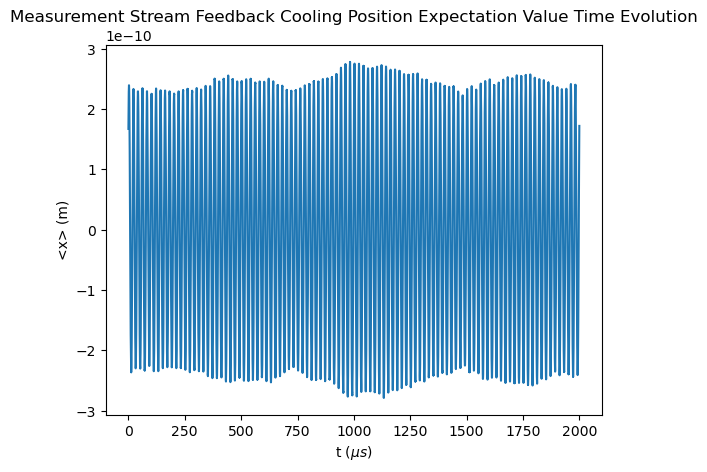

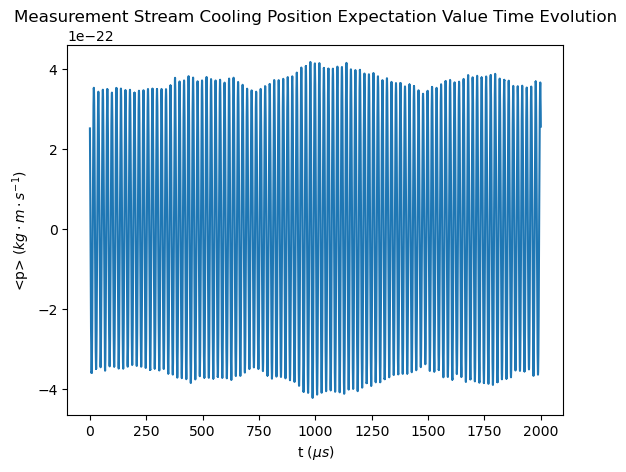

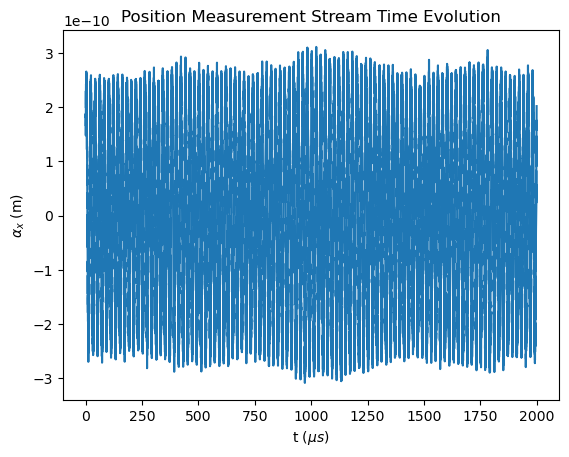

In [11]:
plt.figure()
plt.plot(t_real_arr*10**6, exp_x_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Measurement Stream Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Measurement Stream Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, alpha_x_stream_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\alpha_{x}$ (m)")
plt.title("Position Measurement Stream Time Evolution")
plt.show()

In [8]:
def t_eff(p_sq, x_sq, m, w):
    kB = 1.3806*10**-23
    
    T_eff = (p_sq/m + m*w**2*x_sq)/(2*kB)
    return T_eff
    

In [17]:
gamma_list = np.logspace(-3, 0.5, num=6)
gamma_list_real = gamma_list* 50000
w_real = 50000 * 2*np.pi  #rad/s
m_bead = 4.8e-18 #kg
T_list = []
T_list_cond = []
gamma_list

array([1.00000000e-03, 5.01187234e-03, 2.51188643e-02, 1.25892541e-01,
       6.30957344e-01, 3.16227766e+00])

In [18]:

for gamma in gamma_list:
    t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = sho_expects(del_t=0.1,period_number=5000, eta=1, k=0.05, gamma=gamma, x0=20, p0=20)
    x_sq_real = np.mean(exp_x_sq_real[-2500:])
    p_sq_real = np.mean(exp_p_sq_real[-2500:])

    t_e = t_eff(p_sq_real, x_sq_real, m=m_bead, w=w_real)
    T_list.append(t_e)
    

In [19]:

for gamma in gamma_list:
    t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = sho_expects(del_t=0.1,period_number=5000, eta=1, k=0.05, gamma=gamma, x0=20, p0=20)
    x_sq_real = np.mean(exp_x_sq_real[-2500:])
    p_sq_real = np.mean(exp_p_sq_real[-2500:])
    var_x_cond = np.mean(var_x_real[-2500:])
    var_p_cond = np.mean(var_p_real[-2500:])
    x_sq = x_sq_real + var_x_cond
    p_sq = p_sq_real + var_p_cond
    t_e = t_eff(p_sq, x_sq, m=m_bead, w=w_real)
    T_list_cond.append(t_e)

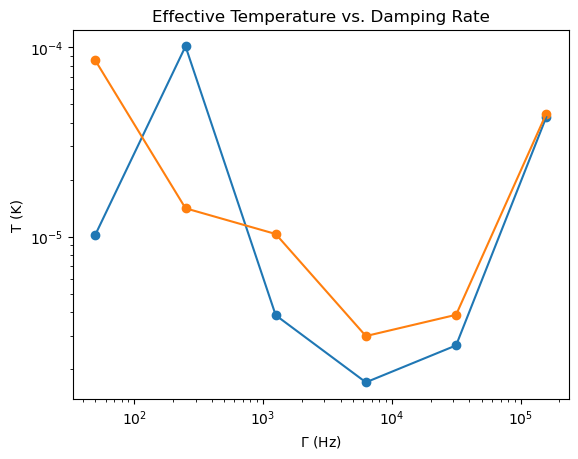

In [20]:
plt.figure()
plt.scatter(gamma_list_real, np.array(T_list))
plt.plot(gamma_list_real, np.array(T_list))
plt.scatter(gamma_list_real, np.array(T_list_cond))
plt.plot(gamma_list_real, np.array(T_list_cond))
plt.xlabel(r"$\Gamma$ (Hz)")
plt.ylabel("T (K)")
plt.title("Effective Temperature vs. Damping Rate")
plt.loglog()
plt.show()